In [1]:
import numpy as np # Used for Linear Algebra
import pandas as pd # Used for data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Social_Network_Ads.csv')

In [4]:
df = df.iloc[:, 2:]

In [6]:
df.sample(5)

,Age,EstimatedSalary,Purchased
285,37,93000,1
184,33,60000,0
28,29,43000,0
172,26,118000,0
384,57,33000,1


In [68]:
from sklearn.model_selection import train_test_split

x = df.iloc[:, 0:2]
y = df.iloc[:, -1]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=0)

x_train.shape, x_test.shape

((240, 2), (160, 2))

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(x_train)

# You only learn from the training set, but you transform both of them
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [70]:
scaler.mean_

array([3.77208333e+01, 6.79625000e+04])

In [71]:
x_train_scaled

array([[-2.66990686e-01, -2.03814684e-01],
       [-1.64078656e+00,  1.09774515e-03],
       [-9.53888624e-01, -7.01459153e-01],
       [ 3.21778974e-01,  5.57288623e-01],
       [-7.07341328e-02, -1.02346440e+00],
       [-1.05201690e+00,  6.45108235e-01],
       [ 1.25522421e-01, -7.60005562e-01],
       [-9.53888624e-01,  1.61112397e+00],
       [-6.59503793e-01,  1.46475795e+00],
       [-1.24827345e+00,  5.57288623e-01],
       [-2.66990686e-01,  8.89173575e-02],
       [-7.07341328e-02,  5.96441534e-02],
       [-2.66990686e-01, -8.47825174e-01],
       [ 9.10548635e-01, -1.31619644e+00],
       [-2.66990686e-01,  2.31368087e+00],
       [ 1.00867691e+00,  2.05022203e+00],
       [-1.15014518e+00,  5.28015419e-01],
       [-1.24827345e+00,  3.23102990e-01],
       [ 1.40119002e+00,  2.05022203e+00],
       [ 1.30306174e+00, -1.31619644e+00],
       [-2.66990686e-01, -2.33087888e-01],
       [-4.63247240e-01,  1.31839193e+00],
       [-7.57632070e-01,  1.14275271e+00],
       [ 1.

In [72]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

In [73]:
x_train_scaled

,Age,EstimatedSalary
0,-0.266991,-0.203815
1,-1.640787,0.001098
2,-0.953889,-0.701459
3,0.321779,0.557289
4,-0.070734,-1.023464
...,...,...
235,1.008677,-1.111284
236,-0.855760,-0.730732
237,-0.168862,-0.467274
238,-1.052017,-0.408727


In [74]:
np.round(x_train.describe(), 1)

,Age,EstimatedSalary
count,240.0,240.0
mean,37.7,67962.5
std,10.2,34232.3
min,18.0,15000.0
25%,30.0,41750.0
50%,37.0,65500.0
75%,46.0,86250.0
max,60.0,150000.0


In [75]:
np.round(x_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,240.0,240.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,-0.1
75%,0.8,0.5
max,2.2,2.4


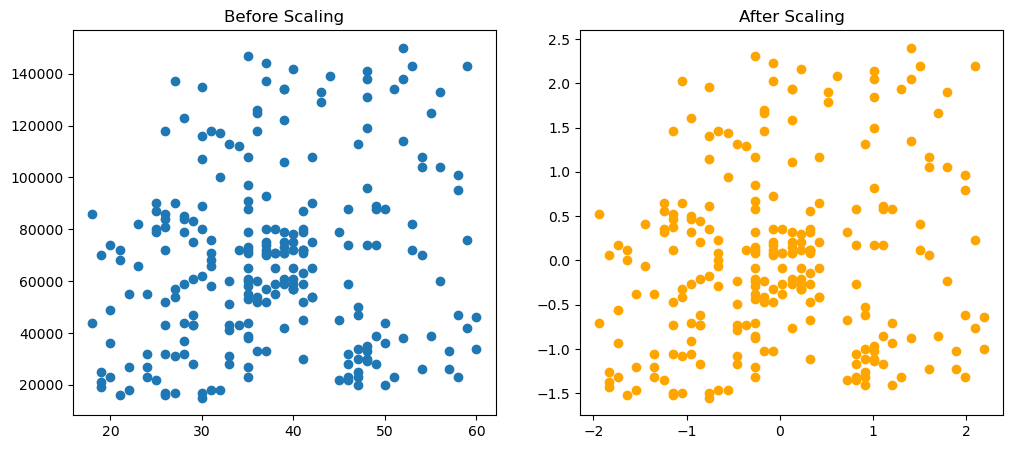

In [76]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(x_train['Age'], x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled['Age'], x_train_scaled['EstimatedSalary'], c='orange')
ax2.set_title("After Scaling")
plt.show()

<Axes: title={'center': 'After Scaling'}, xlabel='Age', ylabel='EstimatedSalary'>

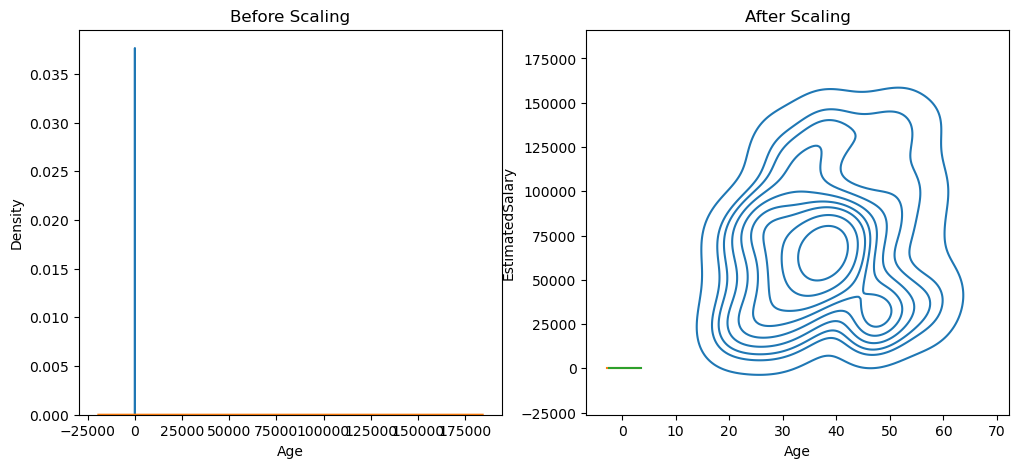

In [77]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# KDE plot for unscaled data
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'], ax=ax1)
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1)

sns.kdeplot(data=x_train, x='Age', y='EstimatedSalary')

ax2.set_title('After Scaling')
sns.kdeplot(x_train_scaled['Age'], ax=ax2)
sns.kdeplot(x_train_scaled['EstimatedSalary'], ax=ax2)

In [78]:
from sklearn.linear_model import LogisticRegression

In [79]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [80]:
lr.fit(x_train, y_train)

LogisticRegression()

In [81]:
lr_scaled.fit(x_train_scaled, y_train)

LogisticRegression()

In [82]:
y_pred = lr.predict(x_test)

In [83]:
y_pred_scaled = lr_scaled.predict(x_test_scaled)

In [84]:
from sklearn.metrics import accuracy_score

In [85]:
print("Actual", accuracy_score(y_test, y_pred))
print("Scaled", accuracy_score(y_test, y_pred_scaled))

Actual 0.8625
Scaled 0.85625


In [87]:
from sklearn.tree import DecisionTreeClassifier

In [88]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [90]:
dt.fit(x_train, y_train)
dt_scaled.fit(x_train_scaled, y_train)

DecisionTreeClassifier()

In [92]:
y_pred = dt.predict(x_test)

In [93]:
y_pred_Scaled = dt.predict(x_test_scaled)

In [95]:
print("Actual", accuracy_score(y_test, y_pred))
print("Scaled", accuracy_score(y_test, y_pred_scaled))

Actual 0.875
Scaled 0.85625
